In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd


In [2]:
from tqdm import tqdm
import h5py

from multicam_tng.utils import convert_tng_mass

# Read data

In [3]:
_file = "../../data/tng100_trees.npz"
with open(_file, 'rb') as fp:
    trees_data = np.load(fp)
    matches = trees_data['matches']
    bdmo = trees_data['bdmo']
    tdmo = trees_data['tdmo']
    bbar = trees_data['bbar']
    tbar = trees_data['tbar']
    


In [4]:
# dmo
subhalo_ids_dark = []
subhalo_mass = []

count = 0
for ii in tqdm(range(0, 64)):
    filename = f'../../data/tng100-dark/fof_subhalo_tab_099.{ii}.hdf5'
    with h5py.File(filename, 'r') as f:

        
        if 'SubhaloMass' in f['Subhalo'].keys():
            for s in f['Subhalo']['SubhaloMass']:
                subhalo_ids_dark.append(count)
                subhalo_mass.append(s)
                count+=1




subhalo_ids_dark = np.array(subhalo_ids_dark)
subhalo_mass = convert_tng_mass(np.array(subhalo_mass)) # log10(Msun / h)
# group_mass = convert_tng_mass2(np.array(group_mass))
# hat_group_mass = convert_tng_mass2(np.array(hat_group_mass))

100%|██████████| 64/64 [00:10<00:00,  6.39it/s]


In [5]:
subhalo_ids_dark.shape, subhalo_mass.shape

((5012155,), (5012155,))

In [6]:
# hydro
subhalo_ids = []
stellar_mass = []
subhalo_mass_hydro = []

count = 0
for ii in tqdm(range(0, 448)):
    filename = f'../../data/tng100/fof_subhalo_tab_099.{ii}.hdf5'
    with h5py.File(filename, 'r') as f:

            

        if 'SubhaloMass' in f['Subhalo'].keys():
            for s in f['Subhalo']['SubhaloMass']:
                subhalo_ids.append(count)
                subhalo_mass_hydro.append(s)
                count+=1

            for s in f['Subhalo']['SubhaloMassInRadType'][:,4]: # 4 = star particles
                stellar_mass.append(s) 


subhalo_ids = np.array(subhalo_ids)
subhalo_mass_hydro = convert_tng_mass(np.array(subhalo_mass_hydro)) # log10(Msun / h)
stellar_mass = convert_tng_mass(np.array(stellar_mass)) # log10(Msun / h)
# group_mass = convert_tng_mass2(np.array(group_mass))
# hat_group_mass = convert_tng_mass2(np.array(hat_group_mass))

100%|██████████| 448/448 [00:10<00:00, 44.74it/s] 
/Users/imendoza/code/multicam-tng-mah/multicam_tng/utils.py:35: RuntimeWarning: divide by zero encountered in log10
  return np.where(gmass > 0, np.log10(gmass * 1e10 / TNG_H), 0)


In [7]:
stellar_mass.shape, subhalo_ids.shape

((4371211,), (4371211,))

In [8]:
matches.shape, bdmo.shape, bbar.shape, tdmo.shape, tbar.shape

((153348,), (869229,), (153348,), (869229, 100), (153348, 100))

In [9]:
bbar.dtype, bdmo.dtype

(dtype([('infall_snap', '<i4'), ('mpeak', '<f4'), ('mpeak_pre', '<f4'), ('is_err', '?'), ('vpeak', '<f4'), ('vpeak_pre', '<f4')]),
 dtype([('infall_snap', '<i4'), ('mpeak', '<f4'), ('mpeak_pre', '<f4'), ('is_err', '?'), ('vpeak', '<f4'), ('vpeak_pre', '<f4')]))

In [10]:
tdmo.dtype, tbar.dtype

(dtype([('mdm', '<f4'), ('mvir', '<f4'), ('vmax', '<f4'), ('ok', '?'), ('is_sub', '?'), ('subfind_id', '<i8'), ('first_sub_idx', '<i8'), ('match', '<i8')]),
 dtype([('mdm', '<f4'), ('mvir', '<f4'), ('vmax', '<f4'), ('ok', '?'), ('is_sub', '?'), ('subfind_id', '<i8'), ('first_sub_idx', '<i8'), ('match', '<i8'), ('stellar_mass', '<f4')]))

# Selection

In [11]:
bp_mass = 1.4e6

212929


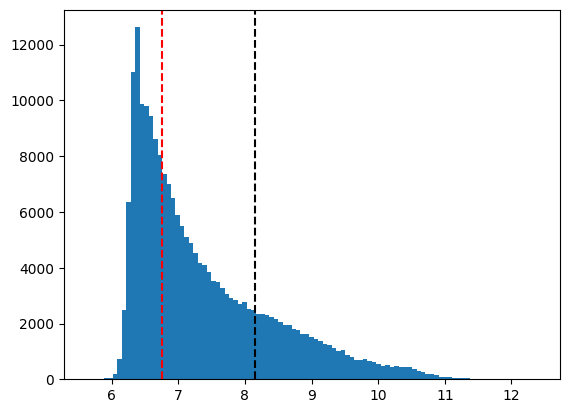

In [12]:
mask = stellar_mass > 0
plt.hist(stellar_mass[mask], bins=101);
plt.axvline(6.75, c='r', ls='--', label='6.75 example cut')
plt.axvline(np.log10(bp_mass * 100), c='k', ls='--', label='>100 particles')
print(sum(mask))

In [13]:
mask1 = (stellar_mass > np.log10(bp_mass * 100))
stellar_mass_final = stellar_mass[mask1]
stellar_mass_final.shape[0]
# sum(stellar_mass > np.log10(bp_mass * 100)).item()

45676

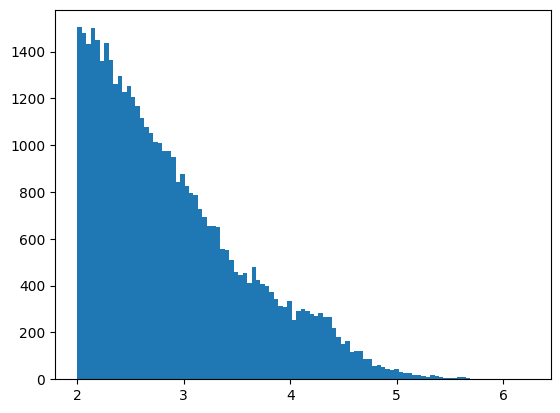

In [14]:
m_star = 1.4e6
n_star_particles = 10**stellar_mass_final  / m_star
plt.hist(np.log10(n_star_particles), bins=101);

In [19]:
# print(sum(n_star_particles > 500))
# mask = n_star_particles > 500
# stellar_mass_final[mask].min()

In [20]:
# how many are discarded with sanity cuts (basically MAH=)
mask2 = (tdmo['ok'][:, -1]) & (tdmo['mdm'][:, -1] > 0) & (~bdmo['is_err'])
sum(mask2) / len(mask2), len(mask2), sum(mask2)

(np.float64(0.6139624885962157), 869229, np.int64(533674))

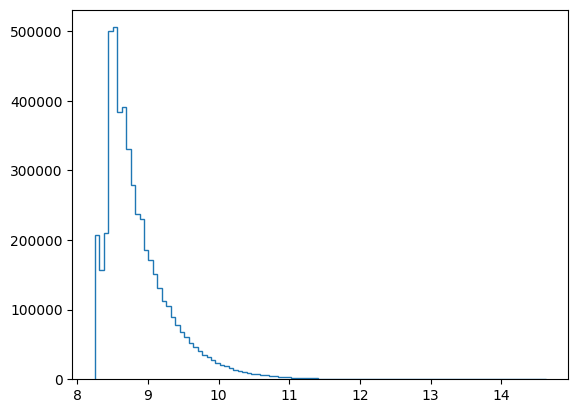

In [21]:
plt.hist(subhalo_mass[subhalo_mass > 0], bins=101, histtype='step');

533674 (5012155,)


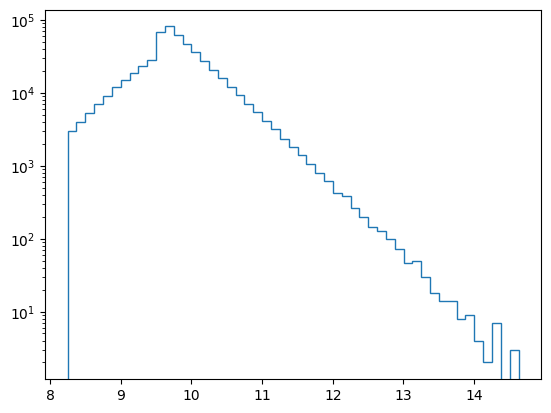

In [22]:
# histogram from tree subhalo mass before masking and after
tree_mask = np.isin(subhalo_ids_dark, tdmo['subfind_id'][:, -1])
_, bins, _ = plt.hist(subhalo_mass[tree_mask], bins=51, histtype='step')
print(tree_mask.sum(), tree_mask.shape)
plt.yscale("log")

In [23]:
# _, bins,_ = plt.hist(subhalo_mass[subhalo_mass > 10], bins=51, histtype='step');
# plt.hist(subhalo_mass[tree_mask], bins=bins, histtype='step');

In [24]:
tree_mask2 = np.isin(tdmo['subfind_id'][:, -1], subhalo_ids_dark)
print(np.all(np.sort(tdmo['subfind_id'][:, -1][tree_mask2]) == np.sort(subhalo_ids_dark[tree_mask])))

## same ids as the one we mask to be "OK"! 
print(np.all(np.sort(tdmo['subfind_id'][:, -1][mask2]) == np.sort(subhalo_ids_dark[tree_mask])))

True
True


In [25]:
# sanity check dark ids
blarr = np.isin(tdmo['subfind_id'][:, -1][mask2], subhalo_ids_dark)
blarr.sum(), blarr.shape, blarr.all()

(np.int64(533674), (533674,), np.True_)

In [26]:
vpeak_final = bdmo['vpeak'][mask2]
vpeak_final.shape

(533674,)

## What about baryon ids?

In [27]:
# curiosity
bar_mask = np.isin(subhalo_ids, tbar['subfind_id'][:, -1])
bar_mask.sum(), bar_mask.shape

(np.int64(101431), (4371211,))

# Vpeak SHAM

In [28]:

import numpy as np
from numpy import ndarray
from scipy.stats import norm, rankdata

def qt(x, y):
    """Performs a quantile transformation from x -> y marginally over first axis.

    Returns what values would x have if they had the same ranks within the y
    distribution.

    CREDIT: Phil Mansfield
    """
    assert x.ndim == 1 and y.ndim == 1
    ranks = rankdata(x, method="ordinal") - 1  # want 0 indexed ranks
    ranks = ranks.astype(float)

    # rescale to size of y and convert to indices/remainders
    ranks *= (len(y) - 1) / (len(x) - 1)
    idx = np.array(ranks, dtype=int)
    remainder = ranks - idx

    # reduce the indices that are too large and make up for it with the remainder
    too_big = idx == len(y) - 1
    idx[too_big], remainder[too_big] = len(y) - 2, 1.0

    # linearly interpolate
    _y = np.sort(y)
    dy = _y[1:] - _y[:-1]
    return _y[idx] + dy[idx] * remainder

In [29]:
stellar_mass_final.shape, vpeak_final.shape

((45676,), (533674,))

In [30]:
n_hydro = len(stellar_mass_final)
_vpeak_final = np.sort(vpeak_final)[-n_hydro:] #pick ndmo highest
_vpeak_final.shape

(45676,)

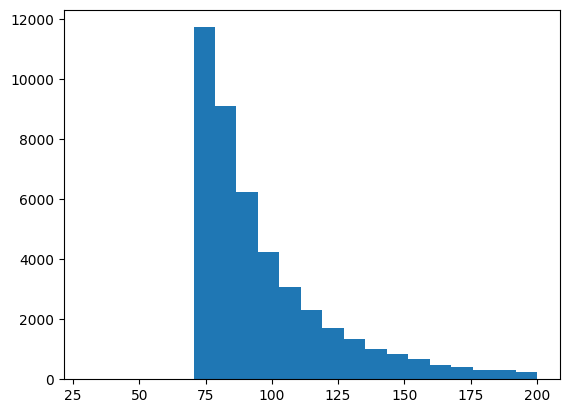

In [31]:
plt.hist(_vpeak_final, bins=21, range=(30, 200));

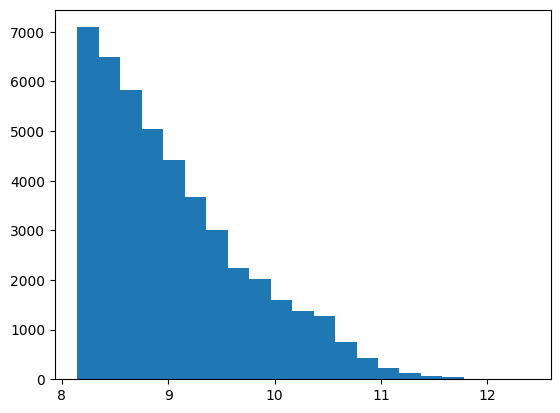

In [32]:
plt.hist(stellar_mass_final, bins=21, );

In [33]:
y_pred = qt(_vpeak_final, stellar_mass_final)
y_pred.shape

(45676,)

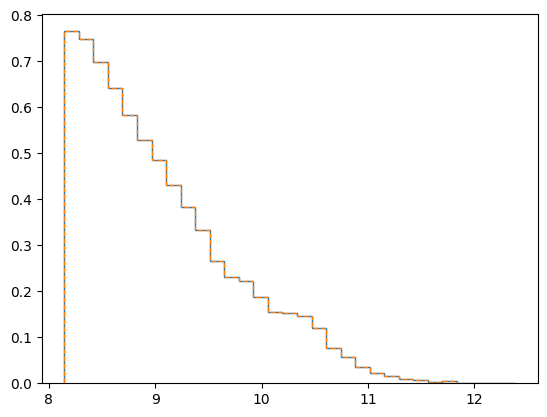

In [34]:
_, bins, _ = plt.hist(stellar_mass_final, bins=31, density=True, histtype='step');
plt.hist(y_pred, bins=31, density=True, histtype='step', ls='--');

In [39]:
sum((stellar_mass_final > 8.75) & ( stellar_mass_final < 9.3))

np.int64(12249)

In [40]:
sum((y_pred > 8.75) & ( y_pred < 9.3))

np.int64(12249)